# Alunos
- **Matheus Peixoto Ribeiro Vieira - 22.1.4104**
- **Pedro Henrique Rabelo Leão de Oliveira - 22.1.4022**

# Objetivo do desafio
A partir de uma base de dados com partidas do campeonato brasileiro de futebol desde o ano 2012 até atualmente, o objetivo é predizer o resultado de um novo confronto, dizendo se a partida acabará em vitória de um dos times ou em empate.

In [1]:
import pandas as pd

df = pd.read_csv('BRA-pre-processed.csv')
df

,Season,Home,Away,Res,PSCH,PSCD,PSCA,MaxCH,MaxCD,MaxCA,...,L_A,GF_A,GA_A,GD_A,WLF_H,DLF_H,LLF_H,WLF_A,DLF_A,LLF_A
0,2012,27,30,1,0.040361,0.135942,0.144214,0.024006,0.125633,0.147500,...,0.000000,0.000000,0.0000,0.513761,0.0,0.0,0.0,0.0,0.0,0.0
1,2012,34,17,1,0.105422,0.087539,0.053816,0.062343,0.080041,0.075000,...,0.000000,0.000000,0.0000,0.513761,0.0,0.0,0.0,0.0,0.0,0.0
2,2012,16,26,2,0.031325,0.154480,0.195920,0.020781,0.143870,0.200556,...,0.000000,0.000000,0.0000,0.513761,0.0,0.0,0.0,0.0,0.0,0.0
3,2012,6,33,2,0.084940,0.083419,0.070348,0.050161,0.077001,0.087500,...,0.000000,0.000000,0.0000,0.513761,0.0,0.0,0.0,0.0,0.0,0.0
4,2012,11,18,0,0.053012,0.101957,0.114668,0.031172,0.091185,0.122500,...,0.000000,0.000000,0.0000,0.513761,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5112,2025,27,9,2,0.021084,0.203913,0.271192,0.011465,0.189463,0.263889,...,0.259259,0.197674,0.2125,0.513761,0.6,0.4,0.0,0.2,0.2,0.6
5113,2025,35,3,1,0.097590,0.052523,0.064369,0.061268,0.047619,0.079167,...,0.185185,0.209302,0.2125,0.522936,0.2,0.4,0.4,0.4,0.0,0.6
5114,2025,14,32,0,0.030120,0.170958,0.170946,0.016840,0.169200,0.180556,...,0.333333,0.209302,0.2750,0.477064,0.6,0.2,0.2,0.4,0.2,0.4
5115,2025,21,34,0,0.044578,0.104016,0.131903,0.027230,0.098278,0.147222,...,0.370370,0.104651,0.3125,0.366972,0.2,0.2,0.6,0.0,0.6,0.4


In [52]:
df.columns

Index(['Season', 'Home', 'Away', 'Res', 'PSCH', 'PSCD', 'PSCA', 'MaxCH',
       'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'W_H', 'D_H', 'L_H',
       'GF_H', 'GA_H', 'GD_H', 'W_A', 'D_A', 'L_A', 'GF_A', 'GA_A', 'GD_A',
       'WLF_H', 'DLF_H', 'LLF_H', 'WLF_A', 'DLF_A', 'LLF_A'],
      dtype='object')

In [2]:
# Separando os dados em treino e teste
train = df[df["Season"] != 2025]
test = df[df["Season"] == 2025]

In [3]:
target_col = "Res"
min_count = train[target_col].value_counts().min()  # here = 1220

# Downsample each class to min_count
train_balanced = (
    train.groupby(target_col, group_keys=False)
      .apply(lambda x: x.sample(n=min_count, random_state=42))
)

# Shuffle the result (optional)
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(train_balanced[target_col].value_counts())

Res
0    1220
1    1220
2    1220
Name: count, dtype: int64


/tmp/ipykernel_44494/1201371128.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_count, random_state=42))


In [4]:
x_train, x_test = train_balanced.iloc[:, 4:], test.iloc[:, 4:]
y_train, y_test = train_balanced.iloc[:, 3], test.iloc[:, 3]

In [5]:
y_train.value_counts()

Res
0    1220
1    1220
2    1220
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [21]:
class_labels = ["Vitória Visitante", "Empate", "Vitória Mandante"]

def test_best_model(best_model, x=x_test, y=y_test):
    y_pred = best_model.predict(x)
    print("Acurácia:", accuracy_score(y, y_pred))
    print(
        classification_report(
            y, y_pred,
            labels=[0,1,2], 
            target_names=class_labels
        )
    )

def display_confusion_matrix(best_model, model_name):
    y_pred = best_model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)

    cm = cm.astype(float) / np.sum(cm, axis=1, keepdims=True)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusão - {model_name}")
    plt.savefig(f'{model_name}_confusion_matrix.png')
    plt.show()

### Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier

In [9]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

rf_grid_search.fit(x_train, y_train)

Fitting 10 folds for each of 81 candidates, totalling 810 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

Melhores parâmetros encontrados: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Acurácia: 0.4550561797752809
                   precision    recall  f1-score   support

Vitória Visitante       0.42      0.42      0.42        43
           Empate       0.25      0.28      0.26        50
 Vitória Mandante       0.62      0.58      0.60        85

         accuracy                           0.46       178
        macro avg       0.43      0.43      0.43       178
     weighted avg       0.47      0.46      0.46       178



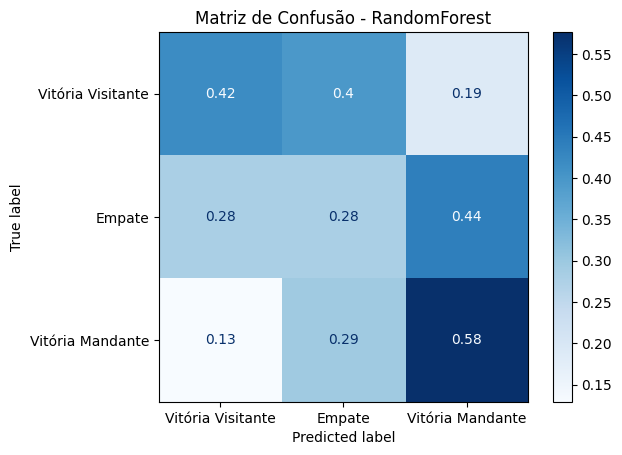

In [22]:
print("Melhores parâmetros encontrados:", rf_grid_search.best_params_)

best_rf = rf_grid_search.best_estimator_

test_best_model(best_rf)
display_confusion_matrix(best_model=best_rf, model_name='RandomForest')

### XGBoost

In [14]:
from xgboost import XGBClassifier

In [15]:
xgboost = XGBClassifier(random_state=42, eval_metric='mlogloss')

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgboost_grid_search = GridSearchCV(
    estimator=xgboost,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

xgboost_grid_search.fit(x_train, y_train)

Fitting 10 folds for each of 108 candidates, totalling 1080 fits


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrai...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.3],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=1)

Melhores parâmetros encontrados: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Acurácia: 0.5112359550561798
                   precision    recall  f1-score   support

Vitória Visitante       0.48      0.56      0.52        43
           Empate       0.37      0.36      0.36        50
 Vitória Mandante       0.62      0.58      0.60        85

         accuracy                           0.51       178
        macro avg       0.49      0.50      0.49       178
     weighted avg       0.52      0.51      0.51       178



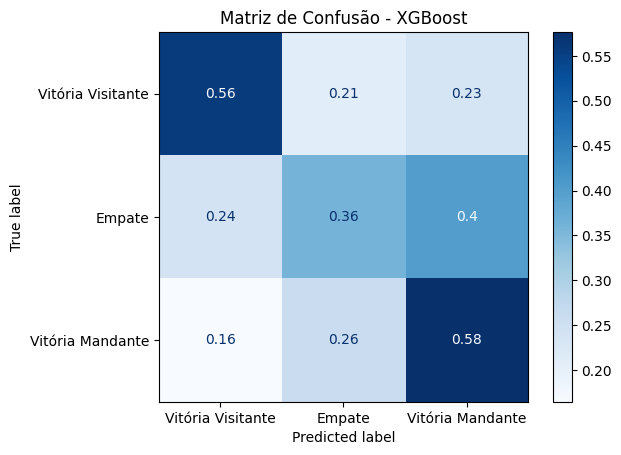

In [23]:
print("Melhores parâmetros encontrados:", xgboost_grid_search.best_params_)

best_xgboost = xgboost_grid_search.best_estimator_

test_best_model(best_xgboost)
display_confusion_matrix(best_model=best_xgboost, model_name='XGBoost')

### KNN

In [24]:
from sklearn.neighbors import KNeighborsClassifier

In [25]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': range(1, 51),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn_grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

knn_grid_search.fit(x_train, y_train)

Fitting 10 folds for each of 300 candidates, totalling 3000 fits


GridSearchCV(cv=10, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': range(1, 51),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=1)

Melhores parâmetros encontrados: {'metric': 'manhattan', 'n_neighbors': 23, 'weights': 'uniform'}


Acurácia: 0.43820224719101125
                   precision    recall  f1-score   support

Vitória Visitante       0.32      0.47      0.38        43
           Empate       0.39      0.46      0.42        50
 Vitória Mandante       0.62      0.41      0.50        85

         accuracy                           0.44       178
        macro avg       0.44      0.45      0.43       178
     weighted avg       0.48      0.44      0.45       178



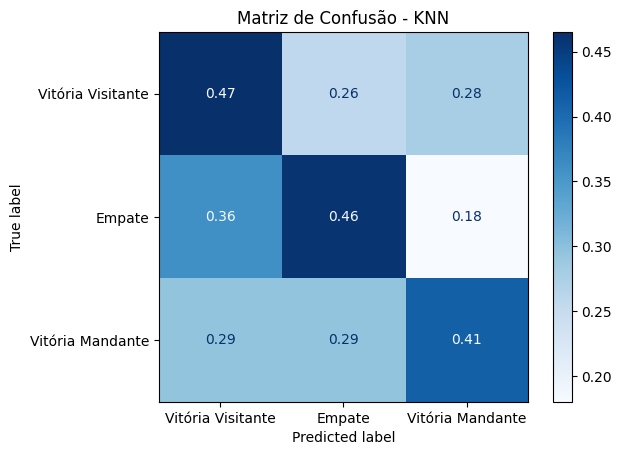

In [26]:
print("Melhores parâmetros encontrados:", knn_grid_search.best_params_)

best_knn = knn_grid_search.best_estimator_

test_best_model(best_knn)
display_confusion_matrix(best_model=best_knn, model_name='KNN')

### Análise dos modelos

Os resultados obtidos para os três modelos de classificação, RandomForest, XGBoost e KNN, apresentam um desempenho bastante próximo entre eles. O RandomForest e o XGBoost tiveram exatamente a mesma acurácia de 0,5225, enquanto o KNN apresentou um valor um pouco inferior, de 0,5169. Essa diferença mínima sugere que, nas condições atuais, o tipo de algoritmo utilizado não exerce tanta influência no desempenho preditivo.

Considerando que o problema envolve prever o resultado de partidas de futebol, com três classes possíveis, vitória do mandante, empate ou vitória do visitante, uma classificação aleatória teria uma acurácia esperada em torno de 33,33%. Assim, os valores obtidos, próximos de 52%, mostram que os modelos conseguem capturar algum padrão nos dados, mas ainda estão distantes de um nível de desempenho que permita confiar nas previsões de forma consistente. Em cenários como esse, a previsão de empates acabam sendo desafiadoras, o que pode contribuir para a limitação dos resultados.